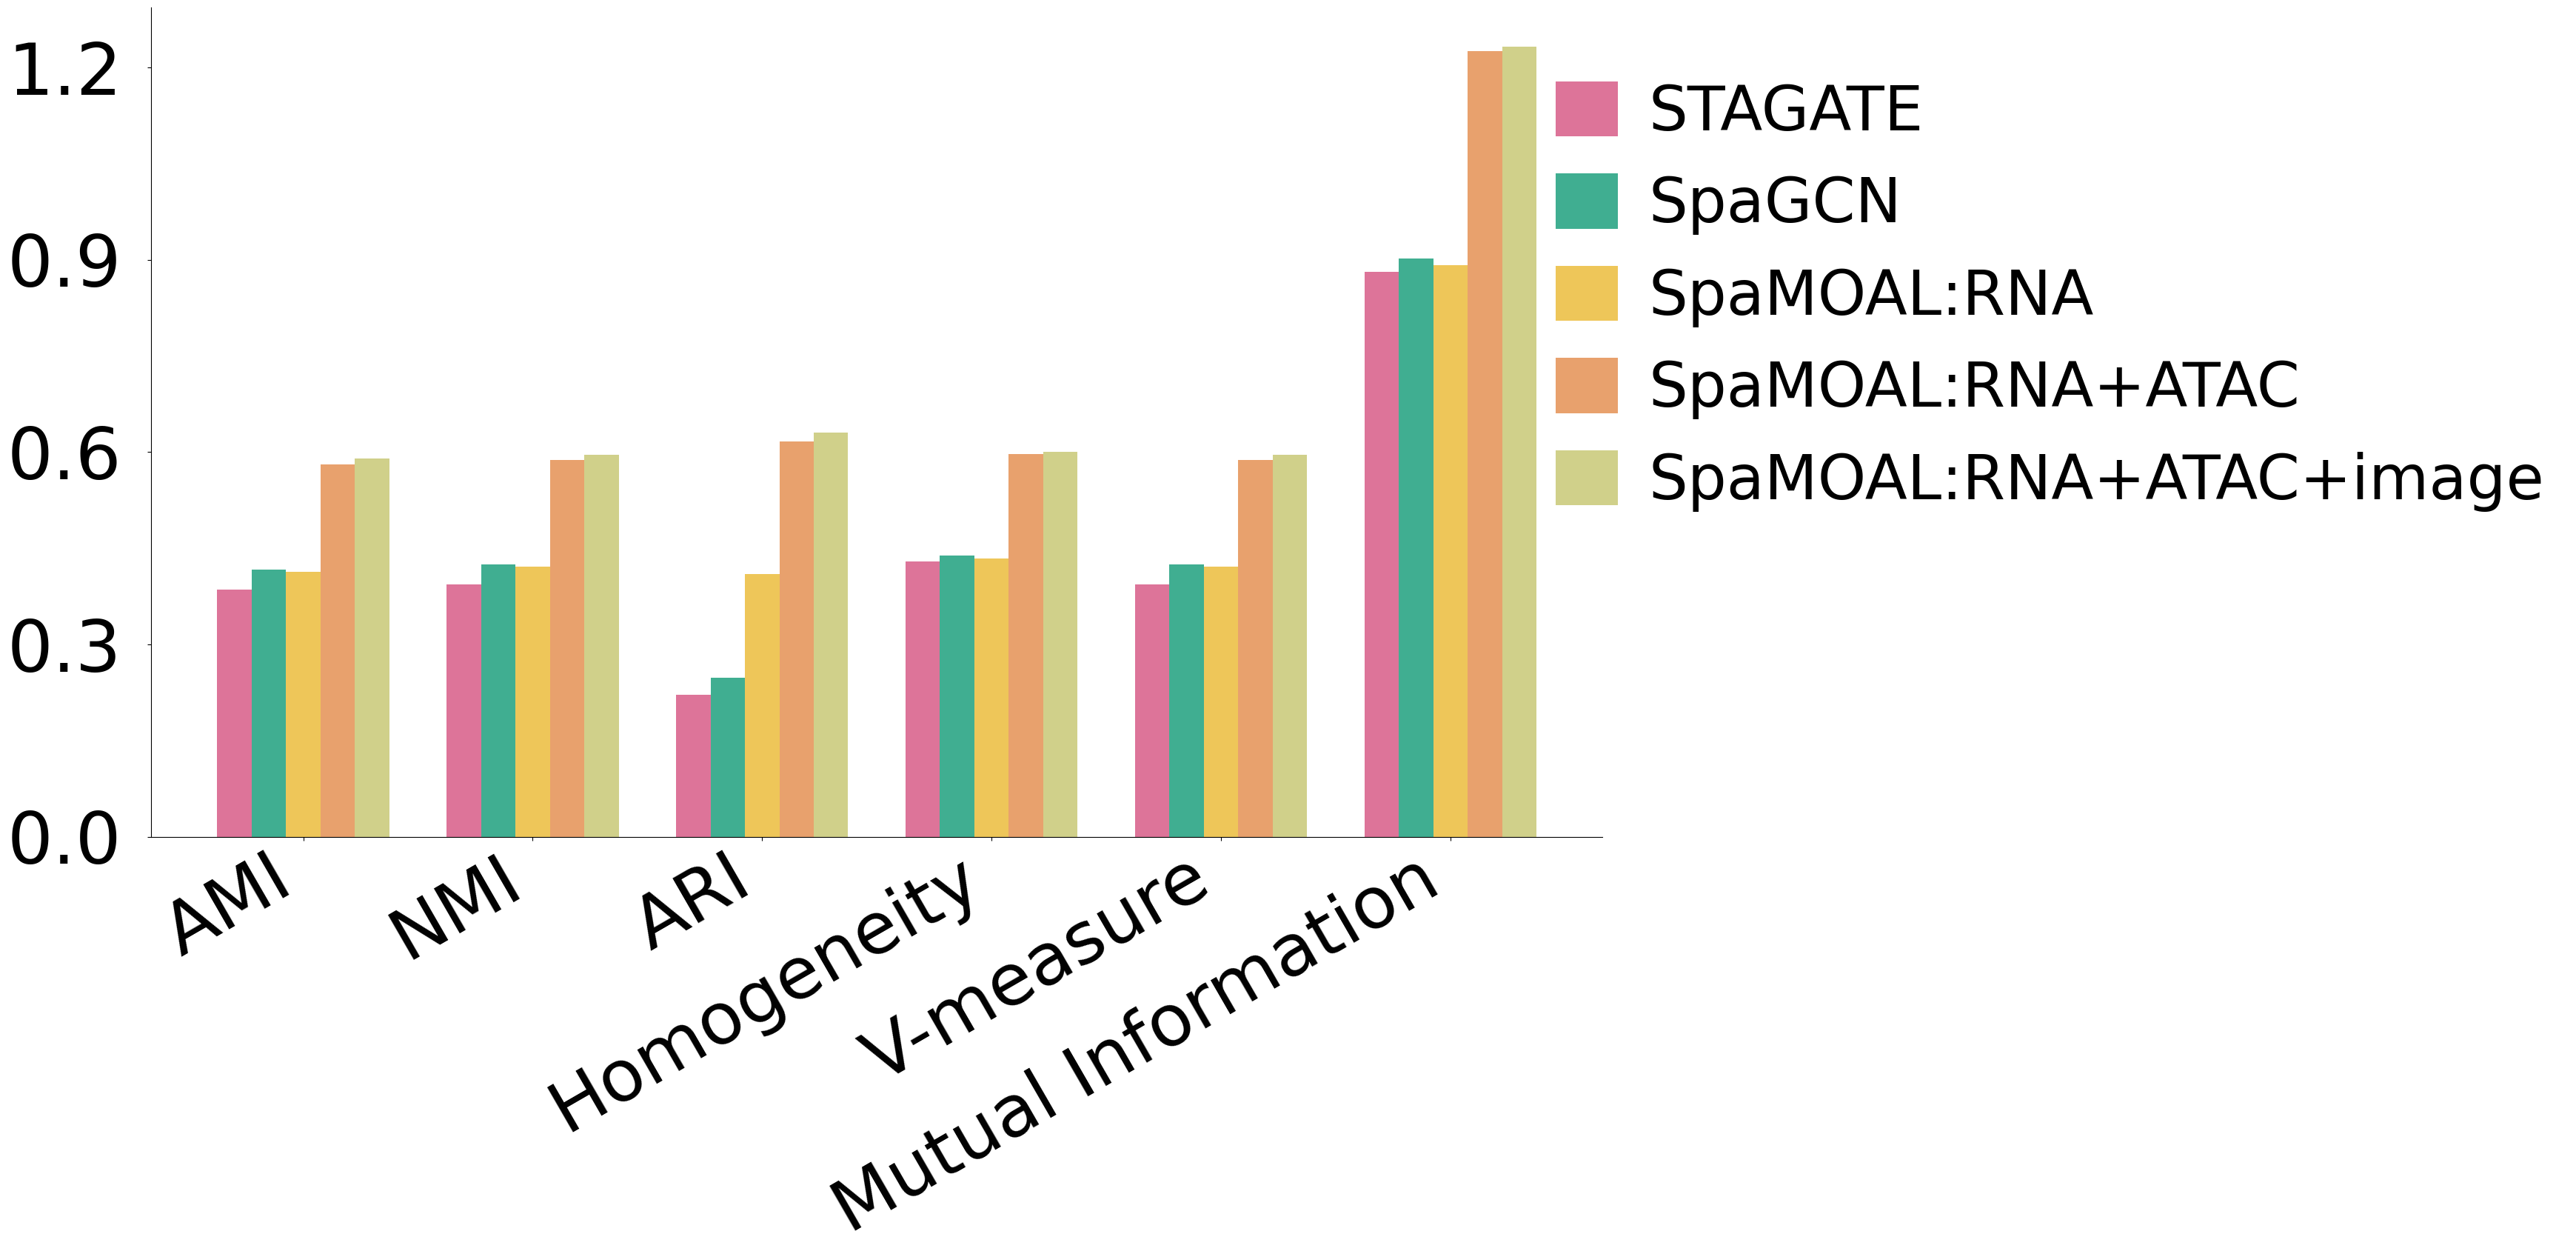

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np

# 定义数据
labels = ['AMI', 'NMI', 'ARI', 'Homogeneity', 'V-measure', 'Mutual Information']
methods = ['STAGATE', 'SpaGCN','SpaMOAL:RNA', 'SpaMOAL:RNA+ATAC','SpaMOAL:RNA+ATAC+image']
data = {
   'STAGATE': [0.3855,	0.3941,	0.2220,	0.4293,	0.3941,	0.8816],
    'SpaGCN': [0.4167,	0.4250,	0.2477,	0.4390,	0.4250,	0.9015],
    'SpaMOAL:RNA': [0.4131,	0.4218,	0.4103,	0.4343,	0.4218,	0.8919],
    'SpaMOAL:RNA+ATAC': [0.5809,	0.5873,	0.6169,	0.5965,	0.5873,	1.2250,],
    'SpaMOAL:RNA+ATAC+image':[0.5898,	0.5961,	0.6302,	0.6001,	0.5961,	1.2323]
    
    
}

# ========== 修复重叠：增大合适画布尺寸 ==========
fig, ax = plt.subplots(figsize=(28, 16))  

bar_width = 0.15
index = np.arange(len(labels))

# 定义颜色列表
colors = ['#DD7499', '#40AE91', '#EEC659', '#E8A16D','#d0d08a']

# 绘制条形图
for i, method in enumerate(methods):
    ax.bar(index + i * bar_width, data[method], bar_width, label=method, color=colors[i])

# 图例（完全保留你原来的样式）
legend = ax.legend(loc='upper right', bbox_to_anchor=(1.7, 1), borderaxespad=0.8, fontsize=60, 
          frameon=False, handlelength=1, handleheight=1, handletextpad=0.5)

# 获取字体属性
legend_text = legend.get_texts()[0]
legend_font = legend_text.get_fontproperties()
font_family = legend_font.get_family()
font_style = legend_font.get_style()
font_weight = legend_font.get_weight()

# X轴（保留原大小、旋转）
ax.set_xticks(index + bar_width * (len(methods) - 1) / 2)
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=70, family=font_family)

# Y轴（保留原大小）
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.yticks(fontsize=70)
ax.tick_params(axis='y', pad=25)

# 隐藏边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ========== 核心修复：强制扩大边距，绝对不重叠 ==========
plt.subplots_adjust(left=0.15, bottom=0.2, right=0.85, top=0.9)

plt.show()